---
title: "EDA Notebook for Kaggle Irrigation Competition"
author: Karisa Kopecek
date: today
format:
  html:
    embed-resources: true
    echo: true
---

## Loading in Data

In [6]:
# Adding libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

TARGET     = 'Irrigation_Need'
ORDER      = ['Low', 'Medium', 'High']

In [7]:
#load packages
import pandas as pd

# Load dataset
train = pd.read_csv("train.csv")

test = pd.read_csv("test.csv")

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'Columns     : {list(train.columns)}')
train.head(3)



Train shape : (630000, 21)
Test shape  : (270000, 20)
Columns     : ['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low


## Data Types

In [8]:
print(train.dtypes)
numeric_cols = train.select_dtypes(include='number').columns.drop('id').tolist()
cat_cols     = train.select_dtypes(include='object').columns.drop(TARGET).tolist()
print(f'\nNumeric features ({len(numeric_cols)})  : {numeric_cols}')
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')

id                           int64
Soil_Type                   object
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                   object
Crop_Growth_Stage           object
Season                      object
Irrigation_Type             object
Water_Source                object
Field_Area_hectare         float64
Mulching_Used               object
Previous_Irrigation_mm     float64
Region                      object
Irrigation_Need             object
dtype: object

Numeric features (11)  : ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
Categorical features (8

## any missing values/duplicates

In [10]:
missing = train.isnull().sum()
print('Missing values (train):')
print(missing[missing > 0] if missing.any() else 'No missing values')
print(f'\nTest set missing values: {test.isnull().sum().sum()}')

Missing values (train):
No missing values

Test set missing values: 0


In [11]:
print(f'Duplicate rows in train: {train.duplicated().sum()}')
print(f'Duplicate rows in test : {test.duplicated().sum()}')

Duplicate rows in train: 0
Duplicate rows in test : 0


## SweetViz

In [13]:
import sweetviz as sv

train_sv = sv.analyze(train)
train_sv.show_html('train.html')

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report train.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## More in depth Target Analysis

  Low     : 369,917  (58.7%)
  Medium  : 239,074  (37.9%)
  High    :  21,009  (3.3%)


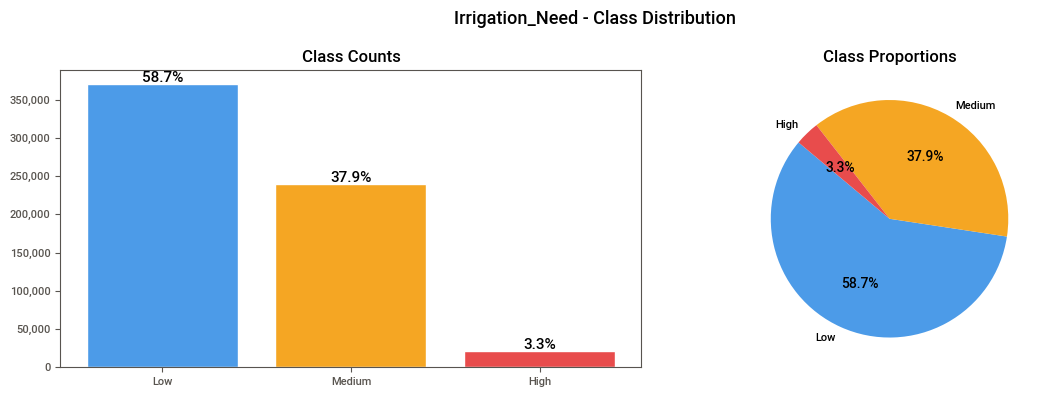

In [14]:
#added these lists of categories and colors I am using to make code easier 
ORDER      = ['Low', 'Medium', 'High']
PALETTE    = {'Low': '#4C9BE8', 'Medium': '#F5A623', 'High': '#E84C4C'}

vc  = train[TARGET].value_counts()          # count how many times each class appears in the target column
pct = (vc / len(train) * 100).round(1)     # convert counts to percentages of total rows and round to 1 decimal place

for cls in ORDER:                          # loop through classes in a specific order
    print(f'  {cls:8s}: {vc[cls]:>7,}  ({pct[cls]}%)')  
    # print class name, count (formatted with commas), and percentage

fig, axes = plt.subplots(1, 2, figsize=(12, 4))  
# create a figure with 2 side-by-side subplots

axes[0].bar(ORDER, [vc[c] for c in ORDER],
            color=[PALETTE[c] for c in ORDER], edgecolor='white')  
# create a bar chart of class counts with custom colors and white borders

axes[0].set_title('Class Counts', fontweight='bold')  
# set title of the bar chart

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))  
# format y-axis numbers with commas (e.g., 1,000 instead of 1000)

for i, cls in enumerate(ORDER):  
    # loop through classes with their index for positioning labels
    axes[0].text(i, vc[cls]+3000, f'{pct[cls]}%', ha='center', fontsize=11)  
    # add percentage labels above each bar

axes[1].pie([vc[c] for c in ORDER], labels=ORDER,
            colors=[PALETTE[c] for c in ORDER], autopct='%1.1f%%', startangle=140)  
# create a pie chart showing class proportions with percentages on slices

axes[1].set_title('Class Proportions', fontweight='bold')  
# set title of the pie chart

plt.suptitle('Irrigation_Need - Class Distribution', fontsize=13, fontweight='bold')  
# set an overall title for the entire figure

plt.tight_layout(); plt.show()  
# adjust spacing to prevent overlap and display the plots

## double checking visually to make sure no huge outliers (kinda already saw on SweetViz, but I don't want to have to look at each number, this was easier for me)

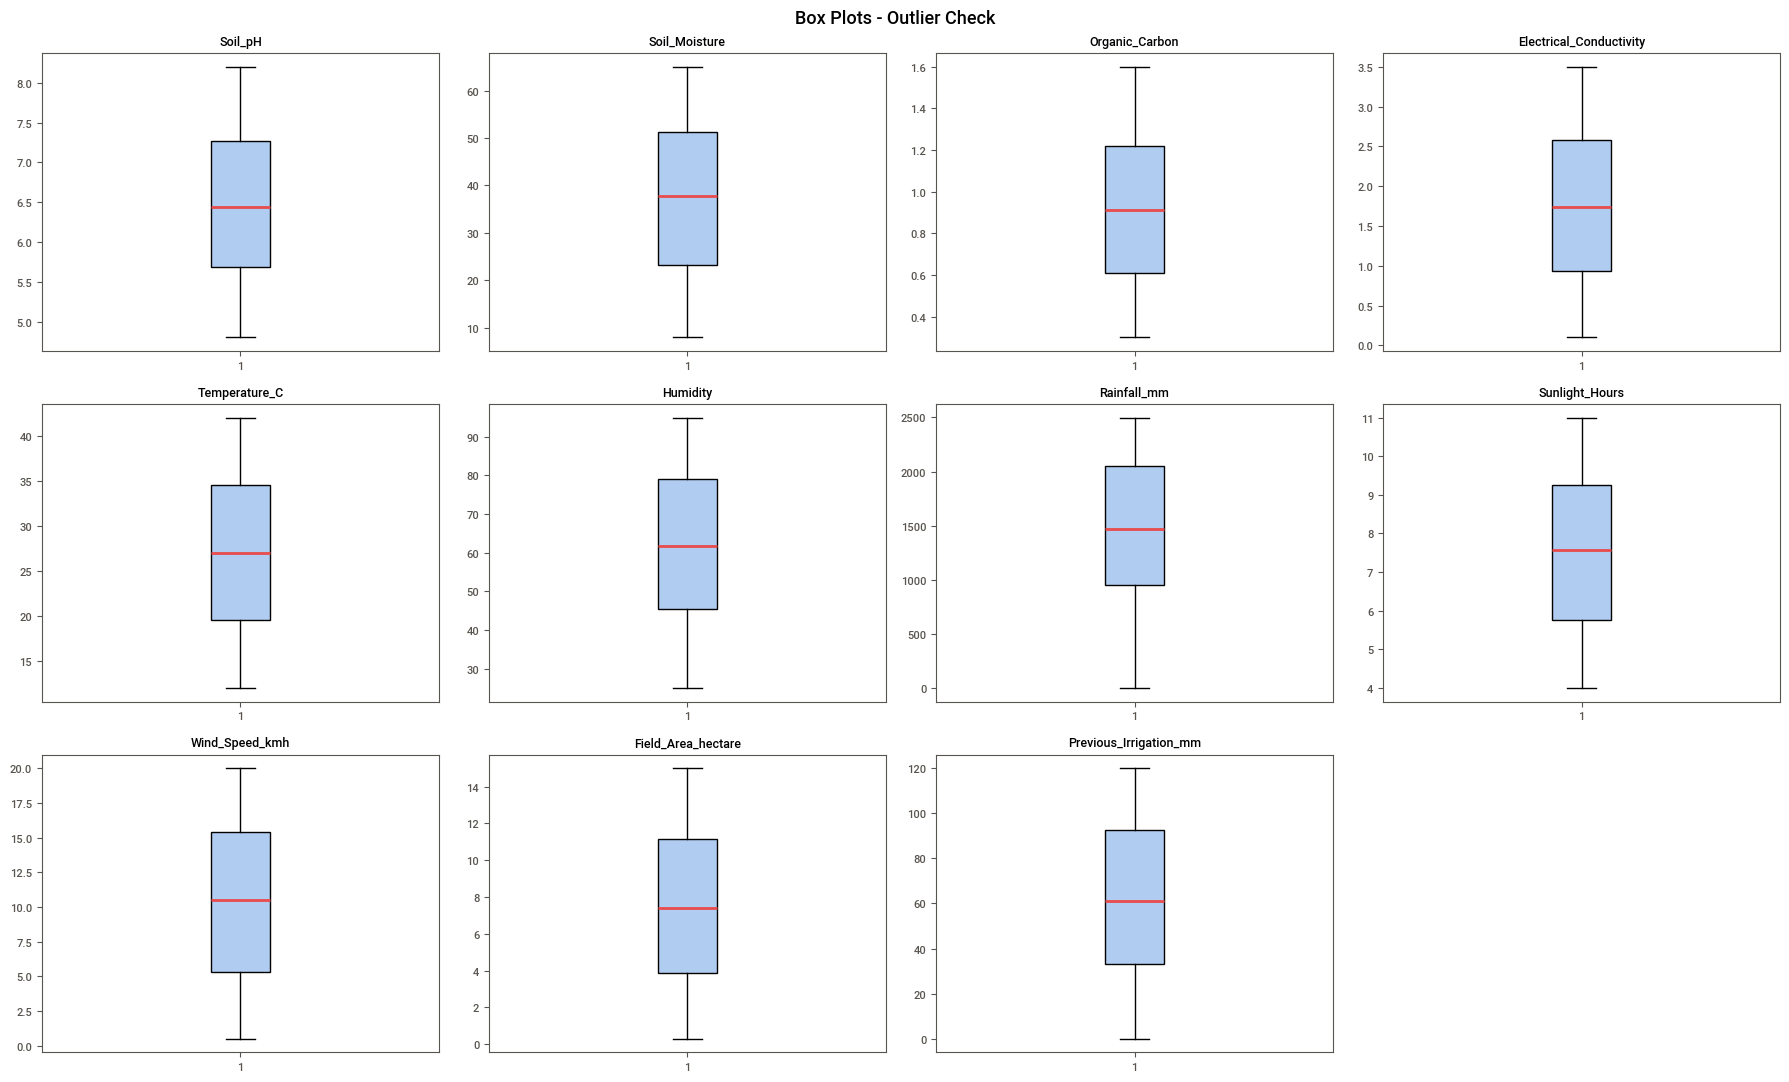

In [18]:
# Goal: Create boxplots for all numeric features to visualize spread and identify potential outliers

# Reproduce boxplots
fig, axes = plt.subplots(3, 4, figsize=(18, 11)); axes = axes.flatten()
# create a 3x4 grid of subplots and flatten it for easy iteration

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    # select the current subplot axis

    ax.boxplot(train[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#B0CCF0'),
               medianprops=dict(color='#E84C4C', linewidth=2),
               flierprops=dict(marker='.', markersize=1, alpha=0.2))
    # plot a boxplot for the column:
    # - dropna() removes missing values
    # - patch_artist fills the box with color
    # - boxprops sets box color
    # - medianprops styles the median line
    # - flierprops styles outlier points

    ax.set_title(col, fontsize=9, fontweight='bold'); ax.tick_params(labelsize=8)
    # set title as column name and adjust tick label size

for j in range(i+1, len(axes)): axes[j].set_visible(False)
# hide any unused subplots if there are fewer features than grid spaces

plt.suptitle('Box Plots - Outlier Check', fontsize=13, fontweight='bold')
# add an overall title for the figure

plt.tight_layout(); plt.show()
# adjust layout to prevent overlap and display the plots

## From discussion post, one of the posts talked about doing an analysis to see class separation so I decided to do my own version of that

<positron-console-cell-21>:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<positron-console-cell-21>:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<positron-console-cell-21>:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<positron-console-cell-21>:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
<positron-console-cell-21>:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


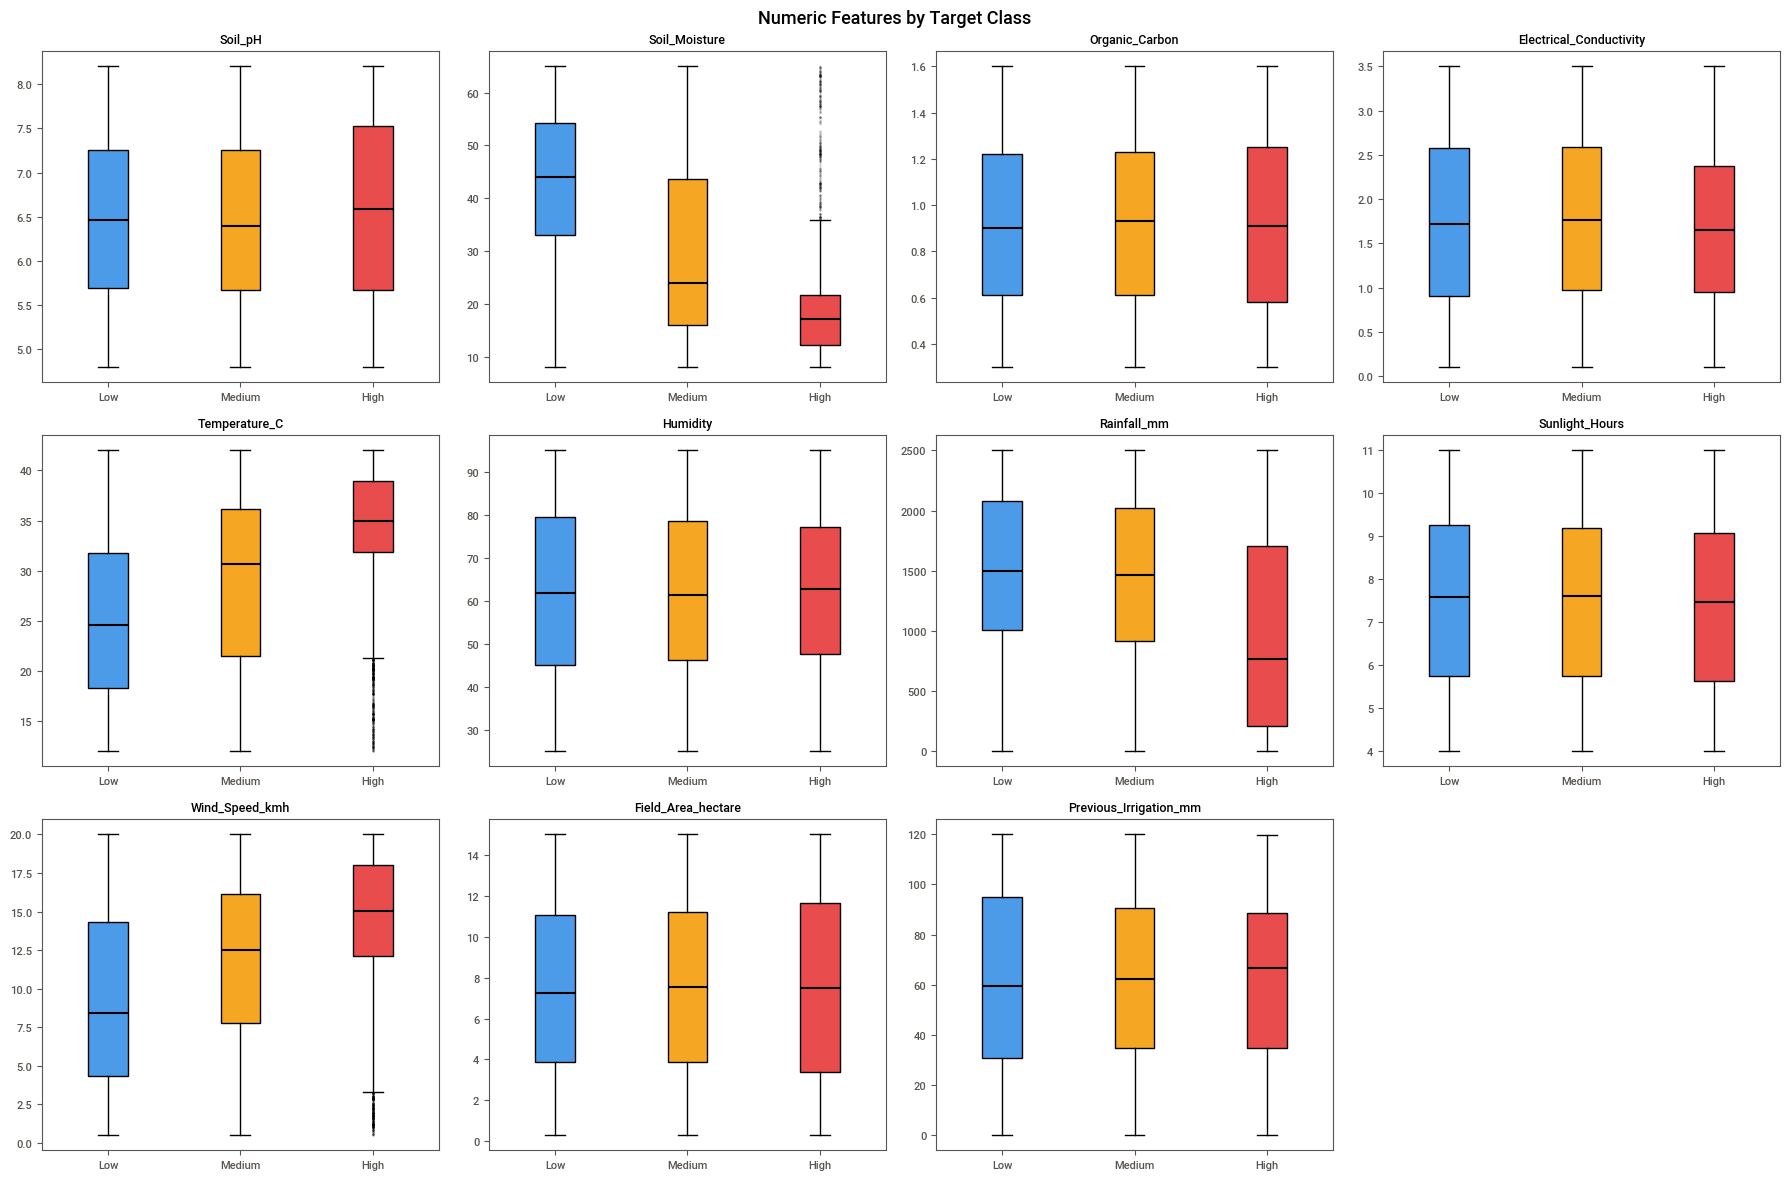

Mean values by class (ordered by class separation):
Irrigation_Need                  Low       Medium        High
Soil_Moisture              43.305902    29.743961   17.669875
Temperature_C              25.347708    28.886683   34.568134
Wind_Speed_kmh              9.216424    11.793668   14.642639
Rainfall_mm              1500.534313  1444.475028  989.156678
Soil_pH                     6.487805     6.465867    6.578282
Electrical_Conductivity     1.731755     1.769208    1.690880
Humidity                   61.949194    61.004887   61.119576
Previous_Irrigation_mm     61.718330    63.181715   63.053300
Field_Area_hectare          7.447241     7.625725    7.530391
Sunlight_Hours              7.511125     7.521290    7.463138
Organic_Carbon              0.920680     0.926116    0.924143


In [21]:
# Goal: See how each numeric feature looks for each class and compare them

fig, axes = plt.subplots(3, 4, figsize=(18, 12)); axes = axes.flatten()
# create a grid of plots

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    # pick the current plot

    data_by_class = [train[train[TARGET]==cls][col].dropna() for cls in ORDER]
    # get the values of this column for each class

    bp = ax.boxplot(data_by_class, patch_artist=True, labels=ORDER,
                    medianprops=dict(color='black', linewidth=1.5),
                    flierprops=dict(marker='.', markersize=1, alpha=0.15))
    # draw boxplots (one box per class)

    for patch, cls in zip(bp['boxes'], ORDER):
        patch.set_facecolor(PALETTE[cls])
    # color each box based on its class

    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=8)
    # set title and make text smaller

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
# hide extra empty plots

plt.suptitle('Numeric Features by Target Class', fontsize=13, fontweight='bold')
# overall title

plt.tight_layout()
plt.show()
# fix spacing and show plots


print('Mean values by class (ordered by class separation):')
# print label

mean_table = train.groupby(TARGET)[numeric_cols].mean().T[ORDER]
# get mean of each numeric feature for each class, and keep class order

std_all = train[numeric_cols].std()
# get overall standard deviation for each feature

separation_score = (mean_table.max(axis=1) - mean_table.min(axis=1)) / std_all
# measure class separation in a scale-aware way

mean_table = mean_table.loc[separation_score.sort_values(ascending=False).index]
# sort features by strongest separation first

print(mean_table.to_string())
# show the reordered table

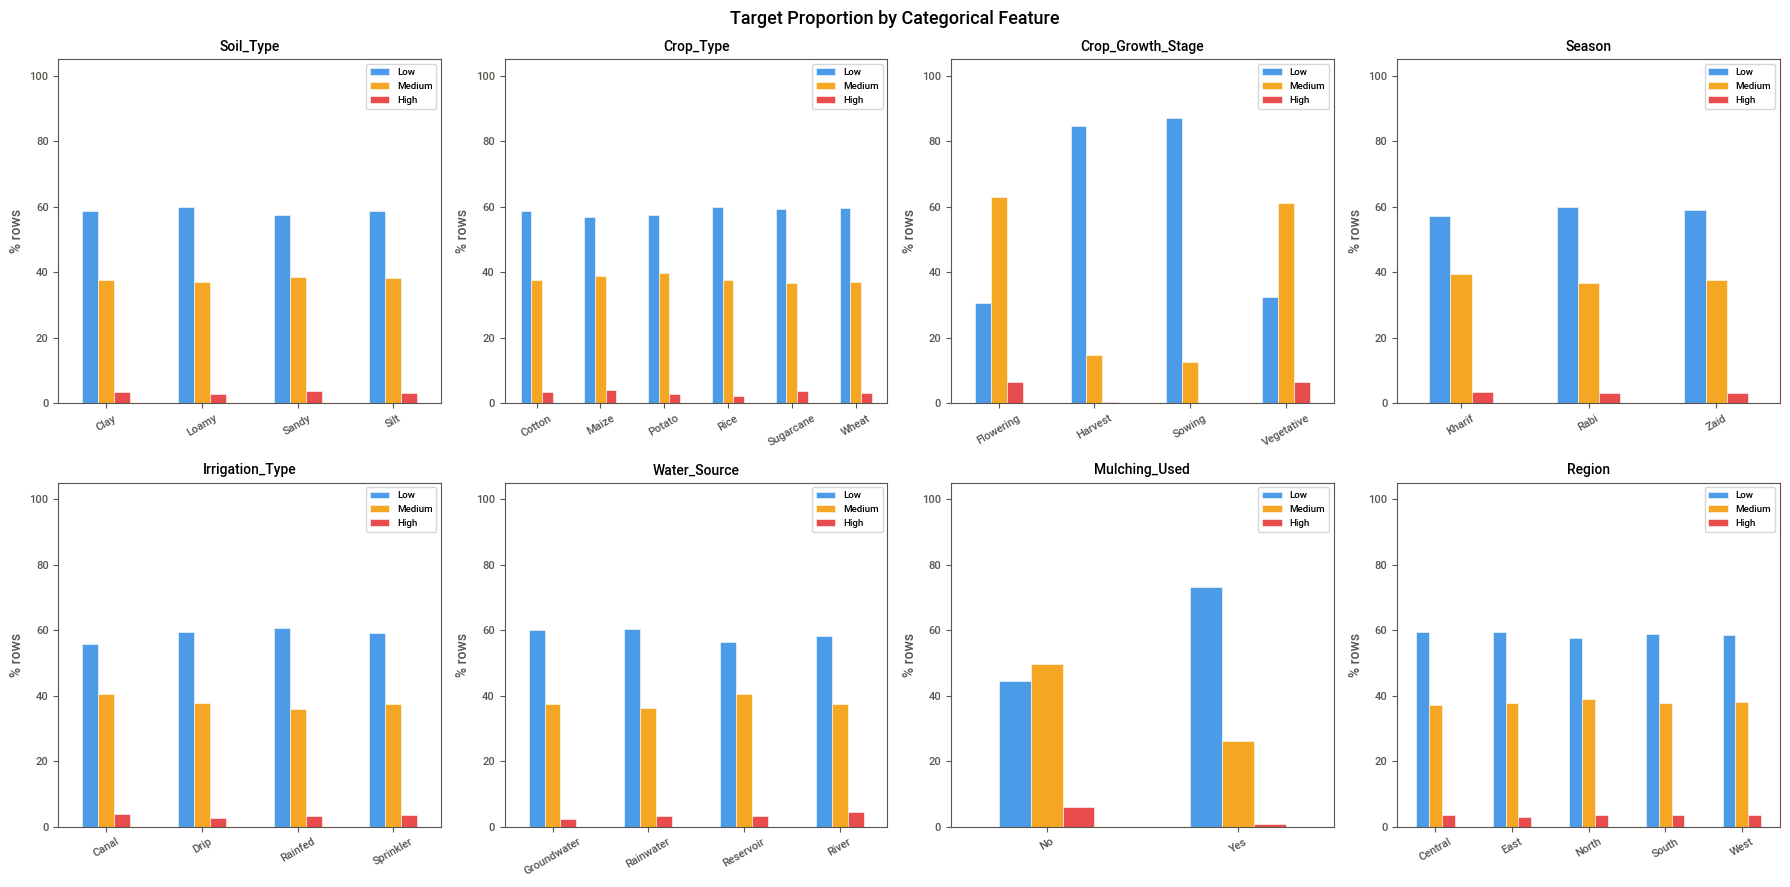

In [22]:
# Goal: See how the target classes are distributed within each category

fig, axes = plt.subplots(2, 4, figsize=(18, 9)); axes = axes.flatten()
# create a grid of plots

for i, col in enumerate(cat_cols):
    ax = axes[i]
    # pick the current plot

    ct = pd.crosstab(train[col], train[TARGET], normalize='index')[ORDER] * 100
    # create a table showing percentage of each class within each category

    ct.plot(kind='bar', ax=ax, color=[PALETTE[c] for c in ORDER],
            edgecolor='white', linewidth=0.4)
    # plot grouped bar chart for class percentages

    ax.set_title(col, fontsize=10, fontweight='bold')
    # set title as column name

    ax.set_xlabel(''); ax.set_ylabel('% rows')
    # remove x label and set y label

    ax.tick_params(axis='x', rotation=30, labelsize=8)
    # rotate category labels for readability

    ax.legend(fontsize=7, title=''); ax.set_ylim(0, 105)
    # style legend and set y-axis limit

plt.suptitle('Target Proportion by Categorical Feature', fontsize=13, fontweight='bold')
# overall title

plt.tight_layout(); plt.show()
# fix spacing and show plots

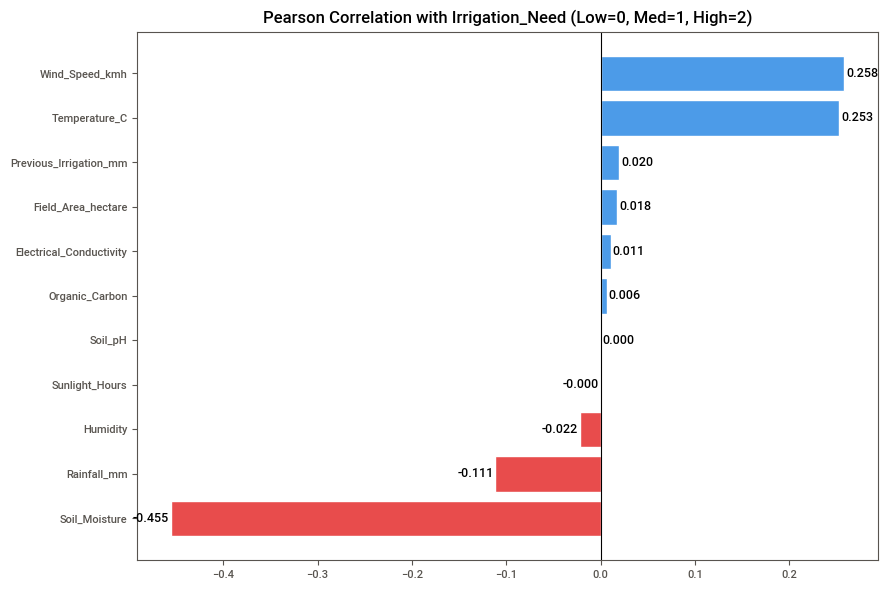

In [24]:
# Goal: See how each numeric feature is related to the target using correlation

from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder(categories=[ORDER])
# create an encoder that converts target classes into numbers based on ORDER

train['target_ord'] = enc.fit_transform(train[[TARGET]])
# convert target column into numeric form (e.g., Low=0, Medium=1, High=2)

corr_target = train[numeric_cols + ['target_ord']].corr()['target_ord'].drop('target_ord').sort_values()
# compute correlation of each numeric feature with the target and sort values

colors = ['#E84C4C' if v < 0 else '#4C9BE8' for v in corr_target]
# choose color based on whether correlation is negative or positive

fig, ax = plt.subplots(figsize=(9, 6))
# create plot

ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
# create horizontal bar chart of correlations

ax.axvline(0, color='black', linewidth=0.8)
# draw vertical line at zero for reference

ax.set_title('Pearson Correlation with Irrigation_Need (Low=0, Med=1, High=2)', fontsize=12, fontweight='bold')
# set title

for i, (idx, val) in enumerate(corr_target.items()):
    ax.text(val+(0.002 if val>=0 else -0.002), i, f'{val:.3f}',
            va='center', ha='left' if val>=0 else 'right', fontsize=9)
    # add correlation value next to each bar

plt.tight_layout(); plt.show()
# fix spacing and show plot

## Any correlation between features will mess up ML model, so seeing if I need to avoid that:

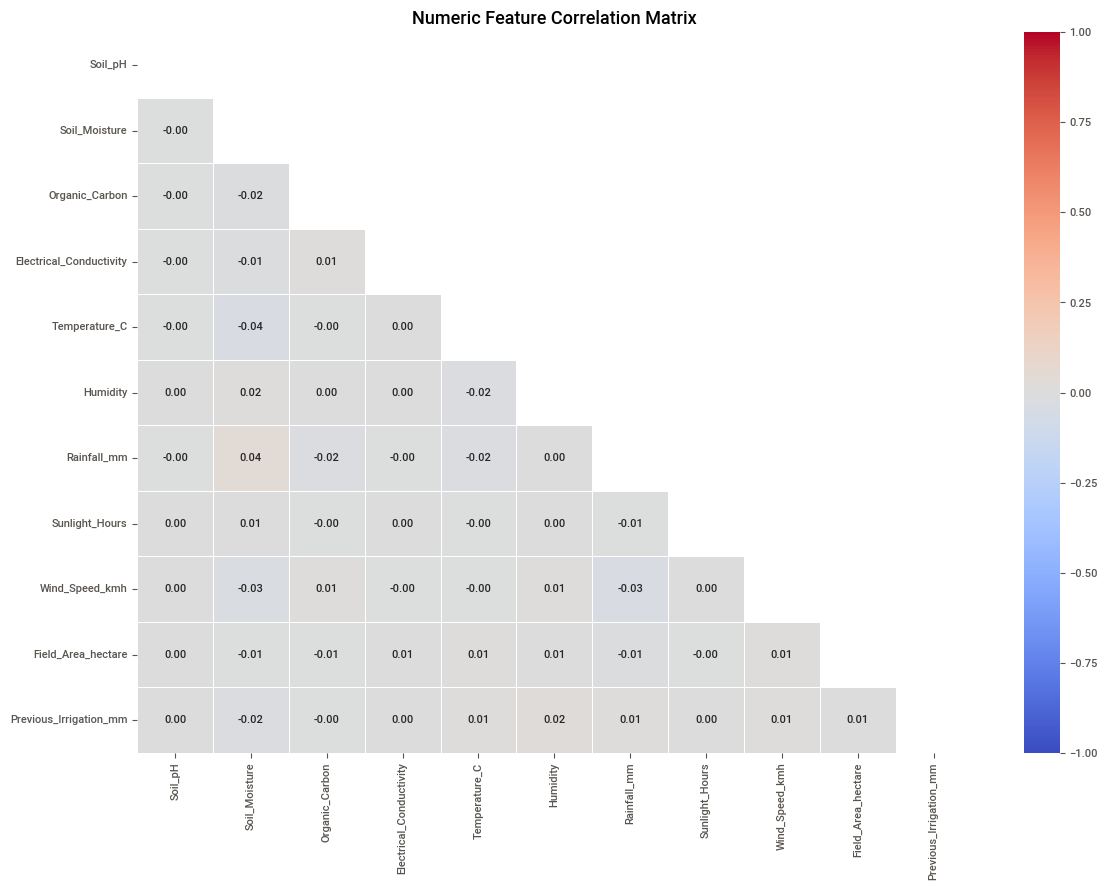

Max absolute pairwise correlation: 0.0445


In [23]:

# Goal: Show how strongly numeric features are related to each other

corr = train[numeric_cols].corr()
# compute correlation matrix for numeric features

fig, ax = plt.subplots(figsize=(12, 9))
# create a figure for the heatmap

mask = np.triu(np.ones_like(corr, dtype=bool))
# create a mask to hide the upper triangle (since correlation is symmetric)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8}, vmin=-1, vmax=1)
# draw heatmap:
# - annot=True shows correlation values
# - cmap sets color scheme
# - center=0 centers colors at zero
# - vmin/vmax fix scale from -1 to 1

ax.set_title('Numeric Feature Correlation Matrix', fontsize=13, fontweight='bold')
# set title

plt.tight_layout(); plt.show()
# fix spacing and show plot

print(f'Max absolute pairwise correlation: {corr.where(~np.eye(len(corr),dtype=bool)).abs().max().max():.4f}')
# print the strongest correlation value (excluding self-correlation)

## for explanation of findings see Kaggle Homework-Karisa Kopecek-karisamarykopecek document section 5